# 🛢️ AULA 3: ANÁLISE DE DADOS PETROFÍSICOS
## Structured AI Learning CV - UDESC

### Objetivos da Aula:
- ✅ Dominar Python avançado (dicionários, list comprehension)
- ✅ Trabalhar com Pandas para análise de dados petrofísicos
- ✅ Processar arquivos LAS (Log ASCII Standard)
- ✅ Implementar limpeza e feature engineering
- ✅ Criar visualizações profissionais com Seaborn

**Data:** Aula 3 - Agosto de 2026
**Prof:** Eduardo Paiva

In [1]:
# Importação de bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from io import StringIO

# Configurações visuais
plt.style.use('default')
sns.set_palette("husl") #husl é uma paleta de cores uniformes
warnings.filterwarnings('ignore')

# Configurações do Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Bibliotecas importadas com sucesso!")
print("Configurações visuais aplicadas")

Bibliotecas importadas com sucesso!
Configurações visuais aplicadas


In [2]:
# Instalação da biblioteca lasio para arquivos LAS
!pip install lasio

import lasio
print("✅ Biblioteca lasio instalada e importada!")
print("📄 Pronta para processar arquivos LAS (Log ASCII Standard)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.8 MB/s eta 0:00:00
✅ Biblioteca lasio instalada e importada!
📄 Pronta para processar arquivos LAS (Log ASCII Standard)


## 🐍 PYTHON AVANÇADO - DICIONÁRIOS E ESTRUTURAS

Vamos começar com conceitos avançados de Python aplicados à petrofísica:
- **Dicionários** para organizar dados de poços
- **List comprehensions** para processamento eficiente
- **Estruturas de dados** para registros (logs) petrofísicos

In [4]:
# Dicionários avançados - Dados de múltiplos poços
dados_pocos = {
    'Poco_A': {
        'localizacao': {'latitude': -27.1234, 'longitude': -48.5678},
        'profundidade_total': 2800.5,
        'formacoes': ['Arenito_Costeiro', 'Folhelho_Marinho', 'Carbonato'],
        'logs_disponiveis': ['GR', 'RT', 'NPHI', 'RHOB', 'SP'],
        'status': 'Produtor',
        'API': 87.3
    },
    'Poco_B': {
        'localizacao': {'latitude': -27.2345, 'longitude': -48.6789},
        'profundidade_total': 3150.8,
        'formacoes': ['Arenito_Fluvial', 'Folhelho_Continental'],
        'logs_disponiveis': ['GR', 'RT', 'NPHI', 'RHOB'],
        'status': 'Exploratório',
        'API': 92.1
    },
    'Poco_C': {
        'localizacao': {'latitude': -27.3456, 'longitude': -48.7890},
        'profundidade_total': 2650.2,
        'formacoes': ['Carbonato_Marinho', 'Arenito_Costeiro'],
        'logs_disponiveis': ['GR', 'RT', 'NPHI', 'RHOB', 'SP', 'CALI'],
        'status': 'Produtor',
        'API': 89.7
    }
}

print("Dicionário de poços criado com:")
print(f"   • {len(dados_pocos)} poços cadastrados")
print(f"   • Dados completos de localização, formações e logs")

# Visualizando estrutura do primeiro poço
print("\n🔍 Estrutura do Poço A:")
for chave, valor in dados_pocos['Poco_A'].items():
    print(f"   {chave}: {valor}")

Dicionário de poços criado com:
   • 3 poços cadastrados
   • Dados completos de localização, formações e logs

🔍 Estrutura do Poço A:
   localizacao: {'latitude': -27.1234, 'longitude': -48.5678}
   profundidade_total: 2800.5
   formacoes: ['Arenito_Costeiro', 'Folhelho_Marinho', 'Carbonato']
   logs_disponiveis: ['GR', 'RT', 'NPHI', 'RHOB', 'SP']
   status: Produtor
   API: 87.3


In [5]:
# List comprehensions avançadas para análise petrofísica

# 1. Extraindo profundidades totais de todos os poços
profundidades = [dados_pocos[poco]['profundidade_total'] for poco in dados_pocos]
print("Profundidades totais:", profundidades)

# 2. Poços produtores usando list comprehension com condição
produtores = [poco for poco in dados_pocos if dados_pocos[poco]['status'] == 'Produtor']
print("Poços produtores:", produtores)

# 3. Logs disponíveis únicos em todos os poços
logs_unicos = list(set([log for poco in dados_pocos
                       for log in dados_pocos[poco]['logs_disponiveis']]))
print("Logs únicos disponíveis:", sorted(logs_unicos))

# 4. Criando dicionário de estatísticas com comprehension
stats_pocos = {poco: {
    'prof_km': round(dados_pocos[poco]['profundidade_total']/1000, 2),
    'num_formacoes': len(dados_pocos[poco]['formacoes']),
    'num_logs': len(dados_pocos[poco]['logs_disponiveis'])
} for poco in dados_pocos}

print("\n Estatísticas dos poços:")
for poco, stats in stats_pocos.items():
    print(f"   {poco}: {stats}")

Profundidades totais: [2800.5, 3150.8, 2650.2]
Poços produtores: ['Poco_A', 'Poco_C']
Logs únicos disponíveis: ['CALI', 'GR', 'NPHI', 'RHOB', 'RT', 'SP']

 Estatísticas dos poços:
   Poco_A: {'prof_km': 2.8, 'num_formacoes': 3, 'num_logs': 5}
   Poco_B: {'prof_km': 3.15, 'num_formacoes': 2, 'num_logs': 4}
   Poco_C: {'prof_km': 2.65, 'num_formacoes': 2, 'num_logs': 6}


## 🐼 PANDAS PARA DADOS PETROFÍSICOS

Agora vamos criar e manipular DataFrames com dados reais de petrofísica:
- **Criação** de DataFrames com logs petrofísicos
- **Indexação** avançada por profundidade
- **Operações** específicas para análise de reservatórios

In [6]:
# Criando DataFrame sintético de logs petrofísicos
np.random.seed(42)  # Para reprodutibilidade

# Definindo intervalo de profundidade (metros)
profundidade = np.arange(2000, 2500, 0.5)  # 1000 pontos, cada 0.5m
n_pontos = len(profundidade)

# Simulando logs petrofísicos realistas
dados_logs = {
    'DEPT': profundidade,
    'GR': np.random.normal(65, 25, n_pontos).clip(0, 200),  # Raios Gama (API)
    'RT': np.random.lognormal(1, 1.5, n_pontos).clip(0.1, 1000),  # Resistividade (ohm.m)
    'NPHI': np.random.normal(0.15, 0.08, n_pontos).clip(-0.05, 0.6),  # Neutrão (fração)
    'RHOB': np.random.normal(2.45, 0.15, n_pontos).clip(1.8, 3.0),  # Densidade (g/cm³)
    'SP': np.random.normal(-20, 15, n_pontos).clip(-100, 20),  # Potencial Espontâneo (mV)
    'CALI': np.random.normal(8.5, 1.2, n_pontos).clip(6, 16)  # Calibre (polegadas)
}

# Criando DataFrame
df_logs = pd.DataFrame(dados_logs)

# Definindo profundidade como índice
df_logs.set_index('DEPT', inplace=True)

print("DataFrame de logs criado:")
print(f"   • {len(df_logs)} pontos de dados")
print(f"   • Intervalo: {df_logs.index.min():.1f} - {df_logs.index.max():.1f} metros")
print(f"   • {len(df_logs.columns)} curvas de log")
print("\n🔍 Primeiras 5 linhas:")
print(df_logs.head())

DataFrame de logs criado:
   • 1000 pontos de dados
   • Intervalo: 2000.0 - 2499.5 metros
   • 6 curvas de log

🔍 Primeiras 5 linhas:
                GR         RT      NPHI      RHOB         SP      CALI
DEPT                                                                  
2000.0   77.417854  22.176500  0.095986  2.163829 -32.952404  7.991488
2000.5   61.543392  10.880264  0.138439  2.320942 -20.468052  7.955903
2001.0   81.192213   2.972625  0.086606  2.387959 -19.729747  6.345228
2001.5  103.075746   1.030037  0.125363  2.733153 -12.910545  8.103892
2002.0   59.146166   7.747227 -0.001489  2.533483 -40.502875  9.379395


In [7]:
# Indexação avançada do DataFrame petrofísico

# 1. Selecionando intervalo de interesse (zona produtora)
zona_interesse = df_logs.loc[2100:2200]  # Entre 2100-2200m
print(f"Zona de interesse: {len(zona_interesse)} pontos")

# 2. Selecionando logs específicos
logs_basicos = df_logs[['GR', 'RT', 'NPHI', 'RHOB']]
print(f"Logs básicos selecionados: {list(logs_basicos.columns)}")

# 3. Filtragem condicional - identificando arenitos (baixo GR)
arenitos = df_logs[df_logs['GR'] < 50]
print(f"Possíveis arenitos: {len(arenitos)} pontos (GR < 50 API)")

# 4. Múltiplas condições - reservatório potencial
reservatorio = df_logs[
    (df_logs['GR'] < 60) &  # Baixo conteúdo argiloso
    (df_logs['RT'] > 5) &   # Alta resistividade
    (df_logs['NPHI'] > 0.1) # Porosidade significativa
]
print(f"Reservatório potencial: {len(reservatorio)} pontos")

# 5. Estatísticas por condição
print(f"\n Porosidade média no reservatório: {reservatorio['NPHI'].mean():.3f}")
print(f"Resistividade média no reservatório: {reservatorio['RT'].mean():.1f} ohm.m")

Zona de interesse: 201 pontos
Logs básicos selecionados: ['GR', 'RT', 'NPHI', 'RHOB']
Possíveis arenitos: 264 pontos (GR < 50 API)
Reservatório potencial: 116 pontos

 Porosidade média no reservatório: 0.184
Resistividade média no reservatório: 17.6 ohm.m


$\Delta$

In [8]:
# Operações avançadas com DataFrames petrofísicos

# 1. Calculando médias móveis para suavização
window = 21  # Janela de 21 pontos (10.5 metros)
df_logs['GR_smooth'] = df_logs['GR'].rolling(window=window, center=True).mean()
df_logs['RT_smooth'] = df_logs['RT'].rolling(window=window, center=True).mean()

# 2. Calculando gradientes (mudanças por metro)
df_logs['GR_gradient'] = df_logs['GR'].diff() / df_logs.index.to_series().diff() #Isto equivale a fazer Δy/Δx
df_logs['RHOB_gradient'] = df_logs['RHOB'].diff() / df_logs.index.to_series().diff()

# 3. Normalização Z-score para comparação
df_logs['GR_zscore'] = (df_logs['GR'] - df_logs['GR'].mean()) / df_logs['GR'].std()
df_logs['RT_zscore'] = (df_logs['RT'] - df_logs['RT'].mean()) / df_logs['RT'].std()

# 4. Criando categorias litológicas baseadas em logs
def classificar_litologia(row):
    if row['GR'] < 50 and row['RT'] > 10:
        return 'Arenito_Limpo'
    elif row['GR'] < 50 and row['RT'] < 10:
        return 'Arenito_Argiloso'
    elif row['GR'] > 100:
        return 'Folhelho'
    else:
        return 'Carbonato_Misto'

df_logs['Litologia'] = df_logs.apply(classificar_litologia, axis=1)

print("🔄 Operações realizadas:")
print("   ✅ Médias móveis (suavização)")
print("   ✅ Gradientes calculados")
print("   ✅ Normalização Z-score")
print("   ✅ Classificação litológica")

# Contagem de litologias
print(f"\n🪨 Distribuição litológica:")
print(df_logs['Litologia'].value_counts())

🔄 Operações realizadas:
   ✅ Médias móveis (suavização)
   ✅ Gradientes calculados
   ✅ Normalização Z-score
   ✅ Classificação litológica

🪨 Distribuição litológica:
Litologia
Carbonato_Misto     645
Arenito_Argiloso    202
Folhelho             91
Arenito_Limpo        62
Name: count, dtype: int64


## 📄 PROCESSAMENTO DE ARQUIVOS LAS

O formato LAS (Log ASCII Standard) é padrão na indústria petrolífera.
Vamos criar e processar um arquivo LAS sintético:

In [9]:
# Criando arquivo LAS sintético para demonstração
las_content = """~VERSION INFORMATION
VERS.                          2.0 : CWLS LOG ASCII STANDARD -VERSION 2.0
WRAP.                          NO  : ONE LINE PER DEPTH STEP

~WELL INFORMATION
STRT.M                      2000.0 : START DEPTH
STOP.M                      2100.0 : STOP DEPTH
STEP.M                        0.5  : STEP
NULL.                      -999.25 : NULL VALUE
COMP.                      UDESC   : COMPANY
WELL.                      POCO_DEMO : WELL
FLD.                       CAMPO_SANTOS : FIELD
LOC.                       BACIA_SANTOS : LOCATION
CNTY.                      BRASIL  : COUNTRY
STAT.                      SC      : STATE
DATE.                      2024-08-20 : LOG DATE

~CURVE INFORMATION
DEPT.M                      : 1  : DEPTH
GR.API                      : 2  : GAMMA RAY
RT.OHMM                     : 3  : RESISTIVITY
NPHI.V/V                    : 4  : NEUTRON POROSITY
RHOB.G/C3                   : 5  : BULK DENSITY

~ASCII
2000.0   45.2   12.5   0.12   2.45
2000.5   48.1   15.3   0.13   2.43
2001.0   52.3   18.7   0.15   2.41
2001.5   46.8   22.1   0.14   2.44
2002.0   43.5   28.9   0.11   2.47
2002.5   41.2   35.6   0.10   2.48
2003.0   39.8   42.3   0.09   2.50
2003.5   44.1   38.7   0.11   2.46
2004.0   47.9   33.2   0.13   2.44
2004.5   51.6   28.8   0.15   2.42
"""

# Salvando arquivo LAS temporário
with open('poco_demo.las', 'w') as f:
    f.write(las_content)

print("📄 Arquivo LAS sintético criado: 'poco_demo.las'")
print("✅ Pronto para processamento com lasio")

📄 Arquivo LAS sintético criado: 'poco_demo.las'
✅ Pronto para processamento com lasio


In [10]:
# Lendo e processando arquivo LAS
las_file = lasio.read('poco_demo.las')

print("📊 INFORMAÇÕES DO ARQUIVO LAS:")
print(f"   • Poço: {las_file.well.WELL.value}")
print(f"   • Campo: {las_file.well.FLD.value}")
print(f"   • Empresa: {las_file.well.COMP.value}")
print(f"   • Profundidade: {las_file.well.STRT.value} - {las_file.well.STOP.value} m")
print(f"   • Passo: {las_file.well.STEP.value} m")

print(f"\n📈 CURVAS DISPONÍVEIS:")
for curve in las_file.curves:
    print(f"   • {curve.mnemonic}: {curve.descr} [{curve.unit}]")

# Convertendo para DataFrame
df_las = las_file.df()
print(f"\n🐼 DataFrame criado:")
print(f"   • {len(df_las)} pontos")
print(f"   • {len(df_las.columns)} curvas")
print("\n🔍 Primeiras linhas:")
print(df_las.head())

📊 INFORMAÇÕES DO ARQUIVO LAS:
   • Poço: POCO_DEMO
   • Campo: CAMPO_SANTOS
   • Empresa: UDESC
   • Profundidade: 2000.0 - 2100.0 m
   • Passo: 0.5 m

📈 CURVAS DISPONÍVEIS:
   • DEPT: DEPTH [M]
   • GR: GAMMA RAY [API]
   • RT: RESISTIVITY [OHMM]
   • NPHI: NEUTRON POROSITY [V/V]
   • RHOB: BULK DENSITY [G/C3]

🐼 DataFrame criado:
   • 10 pontos
   • 4 curvas

🔍 Primeiras linhas:
          GR    RT  NPHI  RHOB
DEPT                          
2000.0  45.2  12.5  0.12  2.45
2000.5  48.1  15.3  0.13  2.43
2001.0  52.3  18.7  0.15  2.41
2001.5  46.8  22.1  0.14  2.44
2002.0  43.5  28.9  0.11  2.47


## 🧹 LIMPEZA E TRATAMENTO DE DADOS

Dados petrofísicos frequentemente contêm:
- **Valores ausentes** (-999.25 é comum em LAS)
- **Outliers** por problemas de ferramenta
- **Ruído** que precisa ser filtrado

In [11]:
# Criando DataFrame sintético de logs petrofísicos (garantindo que df_logs exista para ser usado na próxima célula)
np.random.seed(42)  # Para reprodutibilidade

# Definindo intervalo de profundidade (metros)
profundidade = np.arange(2000, 2500, 0.5)  # 1000 pontos, cada 0.5m
n_pontos = len(profundidade)

# Simulando logs petrofísicos realistas
dados_logs = {
    'DEPT': profundidade,
    'GR': np.random.normal(65, 25, n_pontos).clip(0, 200),  # Raios Gama (API)
    'RT': np.random.lognormal(1, 1.5, n_pontos).clip(0.1, 1000),  # Resistividade (ohm.m)
    'NPHI': np.random.normal(0.15, 0.08, n_pontos).clip(-0.05, 0.6),  # Neutrão (fração)
    'RHOB': np.random.normal(2.45, 0.15, n_pontos).clip(1.8, 3.0),  # Densidade (g/cm³)
    'SP': np.random.normal(-20, 15, n_pontos).clip(-100, 20),  # Potencial Espontâneo (mV)
    'CALI': np.random.normal(8.5, 1.2, n_pontos).clip(6, 16)  # Calibre (polegadas)
}

# Criando DataFrame
df_logs = pd.DataFrame(dados_logs)

# Definindo profundidade como índice
df_logs.set_index('DEPT', inplace=True)

print("DataFrame de logs criado com sucesso antes de adicionar problemas!")

DataFrame de logs criado com sucesso antes de adicionar problemas!


In [12]:
# Adicionando valores problemáticos para demonstrar limpeza
df_sujo = df_logs.copy()

# Introduzindo valores ausentes aleatoriamente
np.random.seed(123)
indices_nan = np.random.choice(df_sujo.index, size=50, replace=False)
df_sujo.loc[indices_nan, 'GR'] = np.nan

# Introduzindo outliers extremos
indices_outlier = np.random.choice(df_sujo.index, size=20, replace=False)
df_sujo.loc[indices_outlier, 'RT'] = df_sujo.loc[indices_outlier, 'RT'] * 100

# Introduzindo valores de NULL típicos de LAS
indices_null = np.random.choice(df_sujo.index, size=30, replace=False)
df_sujo.loc[indices_null, 'NPHI'] = -999.25

print("🧹 PROBLEMAS INTRODUZIDOS NO DATASET:")
print(f"   • {df_sujo['GR'].isna().sum()} valores ausentes em GR")
print(f"   • ~20 outliers extremos em RT")
print(f"   • {(df_sujo['NPHI'] == -999.25).sum()} valores NULL (-999.25) em NPHI")

print(f"\n📊 ESTATÍSTICAS ANTES DA LIMPEZA:")
print(f"   • RT máximo: {df_sujo['RT'].max():.1f} ohm.m (suspeito!)")
print(f"   • NPHI mínimo: {df_sujo['NPHI'].min():.2f} (valor NULL!)")

🧹 PROBLEMAS INTRODUZIDOS NO DATASET:
   • 50 valores ausentes em GR
   • ~20 outliers extremos em RT
   • 30 valores NULL (-999.25) em NPHI

📊 ESTATÍSTICAS ANTES DA LIMPEZA:
   • RT máximo: 3492.9 ohm.m (suspeito!)
   • NPHI mínimo: -999.25 (valor NULL!)


In [13]:
# Processo sistemático de limpeza de dados

# 1. Substituindo valores NULL típicos de LAS
df_limpo = df_sujo.copy()
df_limpo = df_limpo.replace(-999.25, np.nan)
df_limpo = df_limpo.replace(-999, np.nan)

print("✅ Passo 1: Valores NULL convertidos para NaN")

# 2. Detectando outliers usando método IQR
def detectar_outliers_iqr(serie, multiplicador=1.5):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - multiplicador * IQR
    limite_sup = Q3 + multiplicador * IQR
    return (serie < limite_inf) | (serie > limite_sup)

# Aplicando detecção de outliers
outliers_rt = detectar_outliers_iqr(df_limpo['RT'])
outliers_gr = detectar_outliers_iqr(df_limpo['GR'])

print(f"✅ Passo 2: {outliers_rt.sum()} outliers detectados em RT")
print(f"✅ Passo 2: {outliers_gr.sum()} outliers detectados em GR")

# 3. Removendo outliers extremos (substituindo por NaN)
df_limpo.loc[outliers_rt, 'RT'] = np.nan
df_limpo.loc[outliers_gr, 'GR'] = np.nan

# 4. Interpolação para valores ausentes
# Adicionando fillna(method='bfill') para tratar NaNs no início da série
# bfill = (backward fill) preenche esses valores NaN restantes com o próximo valor válido na série

df_limpo['GR'] = df_limpo['GR'].interpolate(method='linear').fillna(method='bfill')
df_limpo['RT'] = df_limpo['RT'].interpolate(method='linear').fillna(method='bfill')
df_limpo['NPHI'] = df_limpo['NPHI'].interpolate(method='linear').fillna(method='bfill')

print("✅ Passo 3: Outliers removidos")
print("✅ Passo 4: Interpolação linear aplicada (incluindo preenchimento de NaNs iniciais)")

# 5. Validação final
print(f"\n🎯 RESULTADO DA LIMPEZA:")
# df_limpo.isna() volta um df com base em álgebra Booleana, retorna true para NAN e false onde não há
# sum() faz a contagem na linha e depois o outro na coluna totalizando
print(f"   • Valores ausentes restantes: {df_limpo.isna().sum().sum()}")
print(f"   • RT máximo após limpeza: {df_limpo['RT'].max():.1f} ohm.m")
print(f"   • NPHI mínimo após limpeza: {df_limpo['NPHI'].min():.3f}")

✅ Passo 1: Valores NULL convertidos para NaN
✅ Passo 2: 117 outliers detectados em RT
✅ Passo 2: 3 outliers detectados em GR
✅ Passo 3: Outliers removidos
✅ Passo 4: Interpolação linear aplicada (incluindo preenchimento de NaNs iniciais)

🎯 RESULTADO DA LIMPEZA:
   • Valores ausentes restantes: 0
   • RT máximo após limpeza: 20.3 ohm.m
   • NPHI mínimo após limpeza: -0.050


### 🧹 Comparativo: Dados Originais (Sujos) vs. Dados Limpos

Vamos visualizar as primeiras linhas do DataFrame **antes** e **depois** do processo de limpeza para observar as mudanças.

In [14]:
print("PRIMEIRAS LINHAS DO DATAFRAME ORIGINAL (SUJO):")
display(df_sujo.head())
print("\nValores ausentes (NaN) e outliers podem ser visíveis, como em GR e RT.")

PRIMEIRAS LINHAS DO DATAFRAME ORIGINAL (SUJO):


,GR,RT,NPHI,RHOB,SP,CALI
DEPT,,,,,,
2000.0,77.417854,22.176500,0.095986,2.163829,-32.952404,7.991488
2000.5,61.543392,10.880264,0.138439,2.320942,-20.468052,7.955903
2001.0,81.192213,2.972625,0.086606,2.387959,-19.729747,6.345228
2001.5,103.075746,1.030037,0.125363,2.733153,-12.910545,8.103892
2002.0,59.146166,7.747227,-0.001489,2.533483,-40.502875,9.379395



Valores ausentes (NaN) e outliers podem ser visíveis, como em GR e RT.


In [15]:
print("PRIMEIRAS LINHAS DO DATAFRAME LIMPO (df_limpo):")
display(df_limpo.head())
print("\nNote a interpolação em GR, RT e NPHI onde havia NaN ou valores de NULL.")

PRIMEIRAS LINHAS DO DATAFRAME LIMPO (df_limpo):


,GR,RT,NPHI,RHOB,SP,CALI
DEPT,,,,,,
2000.0,77.417854,10.880264,0.095986,2.163829,-32.952404,7.991488
2000.5,61.543392,10.880264,0.138439,2.320942,-20.468052,7.955903
2001.0,81.192213,2.972625,0.086606,2.387959,-19.729747,6.345228
2001.5,103.075746,1.030037,0.125363,2.733153,-12.910545,8.103892
2002.0,59.146166,7.747227,-0.001489,2.533483,-40.502875,9.379395



Note a interpolação em GR, RT e NPHI onde havia NaN ou valores de NULL.


## 🔬 FEATURE ENGINEERING PETROFÍSICO

Criando novas variáveis derivadas essenciais para análise de reservatórios:
- **Porosidade efetiva**
- **Saturação de água**
- **Índices petrofísicos**
- **Classificações automáticas**

In [16]:
# Feature Engineering (atributos de engenharia) específico para petrofísica

# 1. Porosidade efetiva (corrigida por argila)
def calcular_porosidade_efetiva(nphi, gr, gr_clean=30, gr_shale=150):
    """
    Calcula porosidade efetiva usando correção por conteúdo de argila
    """
    # Volume de argila (volume of clay, vcl) usando GR
    vcl = np.clip((gr - gr_clean) / (gr_shale - gr_clean), 0, 1)

    # Porosidade efetiva
    phi_eff = nphi * (1 - vcl)
    return phi_eff, vcl

df_features = df_limpo.copy()
df_features['PHI_EFF'], df_features['VCL'] = calcular_porosidade_efetiva(
    df_features['NPHI'], df_features['GR']
)

print("Feature 1: Porosidade efetiva calculada")

# 2. Saturação de água (Equação de Archie simplificada)
def calcular_saturacao_agua(rt, phi_eff, rw=0.1, a=1, m=2, n=2):
    """
    Saturação de água usando equação de Archie
    """
    # Evitando divisão por zero
    phi_eff_safe = np.clip(phi_eff, 0.01, 1)
    rt_safe = np.clip(rt, 0.1, np.inf)

    # Fator de formação
    F = a / (phi_eff_safe ** m)

    # Saturação de água
    sw = ((F * rw) / rt_safe) ** (1/n)
    return np.clip(sw, 0, 1)

df_features['SW'] = calcular_saturacao_agua(df_features['RT'], df_features['PHI_EFF'])
df_features['SH'] = 1 - df_features['SW']  # Saturação de hidrocarboneto

print("Feature 2: Saturação de água/hidrocarboneto calculada")

# 3. Índices petrofísicos
# Photoelectric Factor (estimado)
df_features['PEF_EST'] = 1.8 + 0.4 * df_features['RHOB']

# Resistivity Index
df_features['RI'] = df_features['RT'] / 1.0  # Normalizado por Rw=1

# Bulk Volume Water
df_features['BVW'] = df_features['PHI_EFF'] * df_features['SW']

print("Feature 3: Índices petrofísicos calculados")

# 4. Classificação automática de qualidade de reservatório
def classificar_qualidade_reservatorio(phi_eff, sw, vcl):
    """
    Classifica qualidade do reservatório baseado em cutoffs
    """
    conditions = [
        (phi_eff > 0.15) & (sw < 0.4) & (vcl < 0.3),  # Excelente
        (phi_eff > 0.12) & (sw < 0.5) & (vcl < 0.4),  # Bom
        (phi_eff > 0.08) & (sw < 0.6) & (vcl < 0.5),  # Regular
        (phi_eff > 0.05) & (sw < 0.8) & (vcl < 0.6)   # Pobre
    ]

    choices = ['Excelente', 'Bom', 'Regular', 'Pobre']

    return np.select(conditions, choices, default='Não-reservatório')

df_features['QUALIDADE_RES'] = classificar_qualidade_reservatorio(
    df_features['PHI_EFF'], df_features['SW'], df_features['VCL']
)

print("Feature 4: Classificação de qualidade aplicada")

# Resumo das novas features
print(f"\n🎯 FEATURES CRIADAS:")
novas_colunas = ['PHI_EFF', 'VCL', 'SW', 'SH', 'PEF_EST', 'RI', 'BVW', 'QUALIDADE_RES']
print(f"   • {len(novas_colunas)} novas variáveis derivadas")

# Distribuição de qualidade
print(f"\n📊 DISTRIBUIÇÃO DE QUALIDADE:")
print(df_features['QUALIDADE_RES'].value_counts())

Feature 1: Porosidade efetiva calculada
Feature 2: Saturação de água/hidrocarboneto calculada
Feature 3: Índices petrofísicos calculados
Feature 4: Classificação de qualidade aplicada

🎯 FEATURES CRIADAS:
   • 8 novas variáveis derivadas

📊 DISTRIBUIÇÃO DE QUALIDADE:
QUALIDADE_RES
Não-reservatório    887
Pobre                62
Bom                  23
Regular              22
Excelente             6
Name: count, dtype: int64


In [17]:
# Análise estatística das features criadas

# Estatísticas descritivas das principais features
features_numericas = ['PHI_EFF', 'VCL', 'SW', 'SH', 'BVW']
estatisticas = df_features[features_numericas].describe()

print("📊 ESTATÍSTICAS DAS FEATURES PETROFÍSICAS:")
print(estatisticas.round(3))

# Correlações entre features
correlacoes = df_features[features_numericas + ['GR', 'RT', 'NPHI', 'RHOB']].corr()

print(f"\n🔗 CORRELAÇÕES PRINCIPAIS:")
print(f"   • PHI_EFF vs NPHI: {correlacoes.loc['PHI_EFF', 'NPHI']:.3f}")
print(f"   • SW vs RT: {correlacoes.loc['SW', 'RT']:.3f}")
print(f"   • VCL vs GR: {correlacoes.loc['VCL', 'GR']:.3f}")
print(f"   • BVW vs PHI_EFF: {correlacoes.loc['BVW', 'PHI_EFF']:.3f}")

# Identificando zonas de interesse para produção
zona_producao = df_features[
    (df_features['QUALIDADE_RES'].isin(['Excelente', 'Bom'])) &
    (df_features['PHI_EFF'] > 0.10) &
    (df_features['SW'] < 0.5)
]

print(f"\n ZONAS DE PRODUÇÃO IDENTIFICADAS:")
print(f"   • {len(zona_producao)} pontos de interesse")
print(f"   • Porosidade média: {zona_producao['PHI_EFF'].mean():.3f}")
print(f"   • Saturação de HC média: {zona_producao['SH'].mean():.3f}")

if len(zona_producao) > 0:
    print(f"   • Intervalo: {zona_producao.index.min():.1f} - {zona_producao.index.max():.1f}m")

📊 ESTATÍSTICAS DAS FEATURES PETROFÍSICAS:
        PHI_EFF       VCL        SW        SH       BVW
count  1000.000  1000.000  1000.000  1000.000  1000.000
mean      0.105     0.298     0.948     0.052     0.095
std       0.063     0.187     0.134     0.134     0.054
min      -0.043     0.000     0.289     0.000    -0.043
25%       0.061     0.156     1.000     0.000     0.061
50%       0.098     0.294     1.000     0.000     0.090
75%       0.144     0.424     1.000     0.000     0.126
max       0.357     0.828     1.000     0.711     0.338

🔗 CORRELAÇÕES PRINCIPAIS:
   • PHI_EFF vs NPHI: 0.862
   • SW vs RT: -0.573
   • VCL vs GR: 0.992
   • BVW vs PHI_EFF: 0.908

 ZONAS DE PRODUÇÃO IDENTIFICADAS:
   • 29 pontos de interesse
   • Porosidade média: 0.204
   • Saturação de HC média: 0.568
   • Intervalo: 2022.5 - 2488.0m


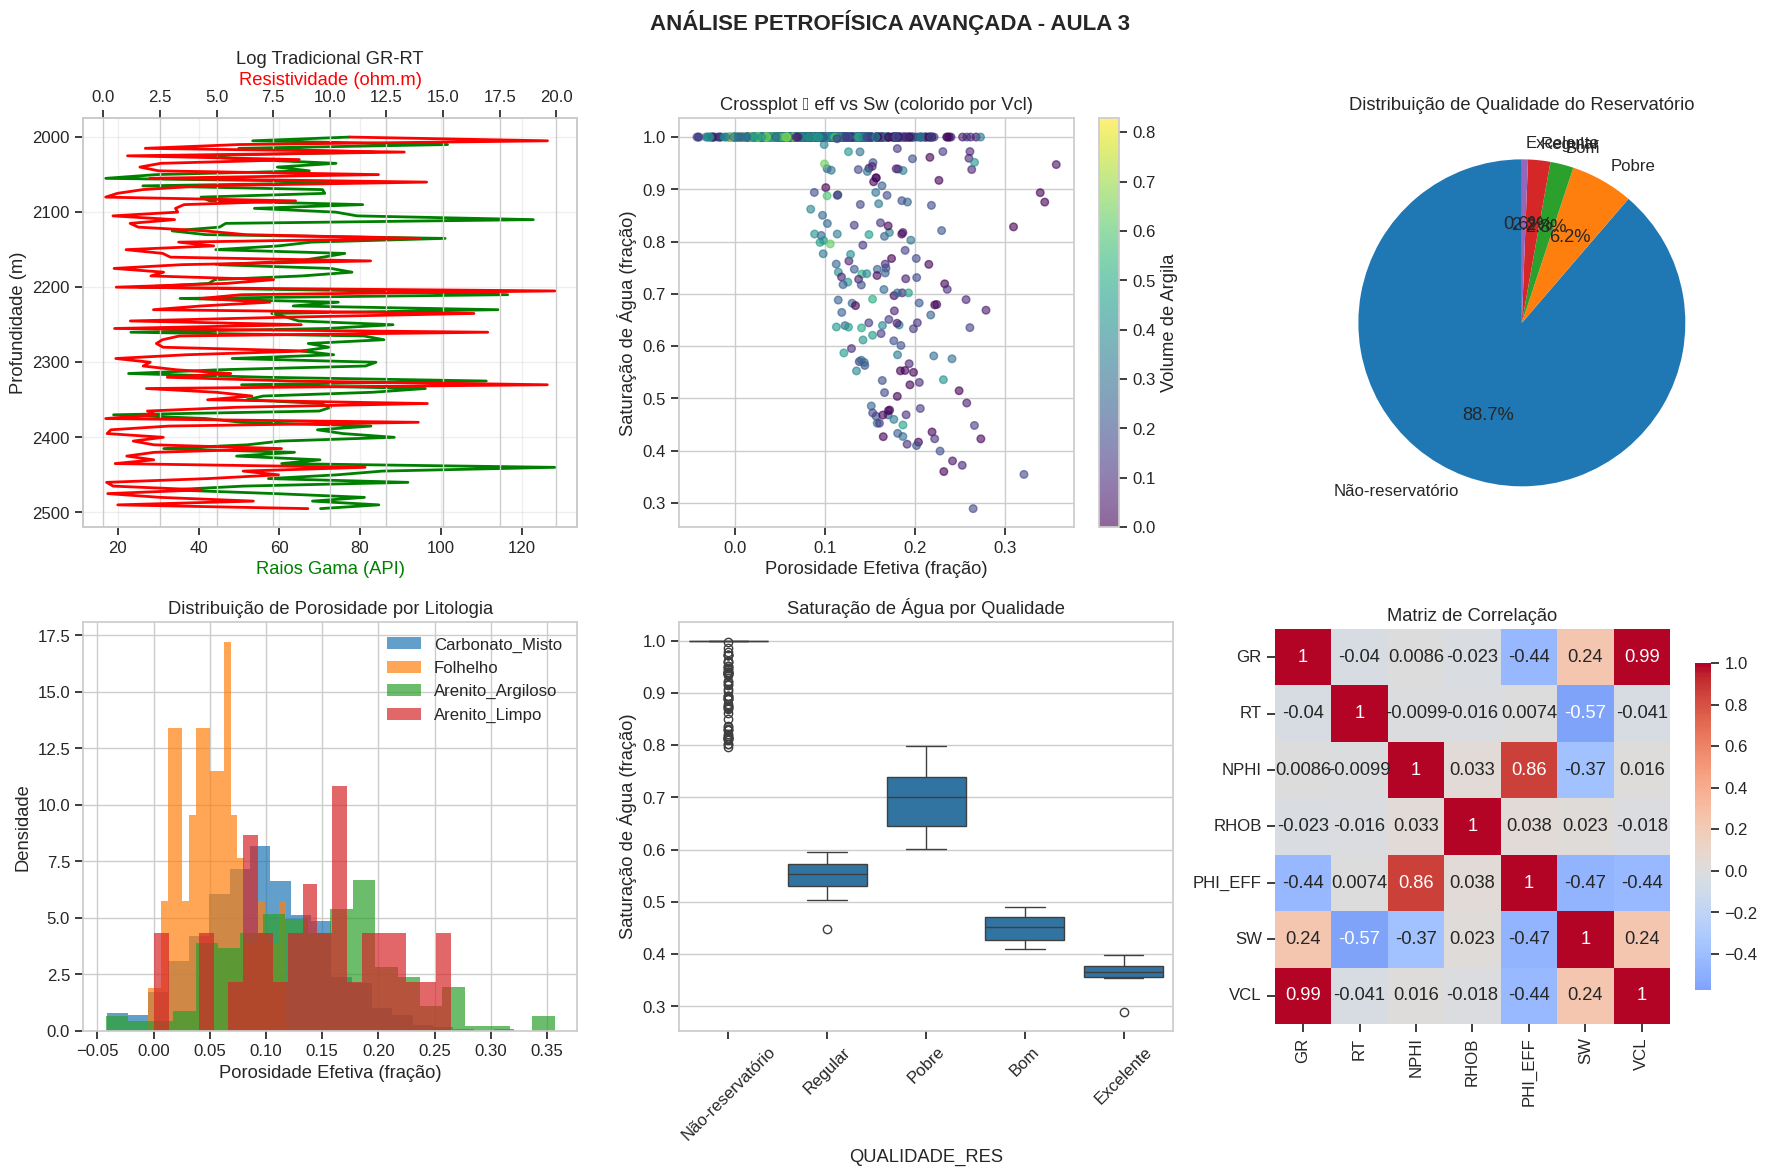

📊 Visualizações criadas com sucesso!


In [18]:
# Configuração avançada para visualizações petrofísicas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# Paleta de cores personalizada para petrofísica
cores_petro = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
sns.set_palette(cores_petro)

# Recriar a coluna 'Litologia' no df_features, já que ela foi criada em df_logs após a cópia para df_features.
def classificar_litologia(row):
    if row['GR'] < 50 and row['RT'] > 10:
        return 'Arenito_Limpo'
    elif row['GR'] < 50 and row['RT'] < 10:
        return 'Arenito_Argiloso'
    elif row['GR'] > 100:
        return 'Folhelho'
    else:
        return 'Carbonato_Misto'
df_features['Litologia'] = df_features.apply(classificar_litologia, axis=1)

# Criando figura principal com subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ANÁLISE PETROFÍSICA AVANÇADA - AULA 3', fontsize=16, fontweight='bold')

# 1. Log plot tradicional - GR e RT
ax1 = axes[0, 0]
prof_plot = df_features.index[::10]  # Subsampling para clareza
ax1.plot(df_features.loc[prof_plot, 'GR'], prof_plot, 'g-', linewidth=2, label='GR')
ax1_twin = ax1.twiny()
ax1_twin.plot(df_features.loc[prof_plot, 'RT'], prof_plot, 'r-', linewidth=2, label='RT')
ax1.set_ylabel('Profundidade (m)')
ax1.set_xlabel('Raios Gama (API)', color='g')
ax1_twin.set_xlabel('Resistividade (ohm.m)', color='r') #Cria um eixo gêmeo no plot e reescala corretamente
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3)
ax1.set_title('Log Tradicional GR-RT')

# 2. Crossplot Porosidade vs Saturação
ax2 = axes[0, 1]
scatter = ax2.scatter(df_features['PHI_EFF'], df_features['SW'],
                     c=df_features['VCL'], cmap='viridis', alpha=0.6, s=30)
ax2.set_xlabel('Porosidade Efetiva (fração)')
ax2.set_ylabel('Saturação de Água (fração)')
ax2.set_title('Crossplot ϕ eff vs Sw (colorido por Vcl)')
plt.colorbar(scatter, ax=ax2, label='Volume de Argila')

# 3. Distribuição de qualidade de reservatório
ax3 = axes[0, 2]
qualidade_counts = df_features['QUALIDADE_RES'].value_counts()
wedges, texts, autotexts = ax3.pie(qualidade_counts.values, labels=qualidade_counts.index,
                                  autopct='%1.1f%%', startangle=90)
ax3.set_title('Distribuição de Qualidade do Reservatório')

# 4. Histograma de porosidade por litologia
ax4 = axes[1, 0]
for litologia in df_features['Litologia'].unique():
    subset = df_features[df_features['Litologia'] == litologia]
    ax4.hist(subset['PHI_EFF'], alpha=0.7, bins=20, label=litologia, density=True)
ax4.set_xlabel('Porosidade Efetiva (fração)')
ax4.set_ylabel('Densidade')
ax4.set_title('Distribuição de Porosidade por Litologia')
ax4.legend()

# 5. Boxplot de saturação por qualidade
ax5 = axes[1, 1]
sns.boxplot(data=df_features, x='QUALIDADE_RES', y='SW', ax=ax5)
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45)
ax5.set_title('Saturação de Água por Qualidade')
ax5.set_ylabel('Saturação de Água (fração)')

# 6. Mapa de calor de correlações
ax6 = axes[1, 2]
corr_matrix = df_features[['GR', 'RT', 'NPHI', 'RHOB', 'PHI_EFF', 'SW', 'VCL']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, ax=ax6, cbar_kws={'shrink': 0.8})
ax6.set_title('Matriz de Correlação')

plt.tight_layout()
plt.show()

print("📊 Visualizações criadas com sucesso!")

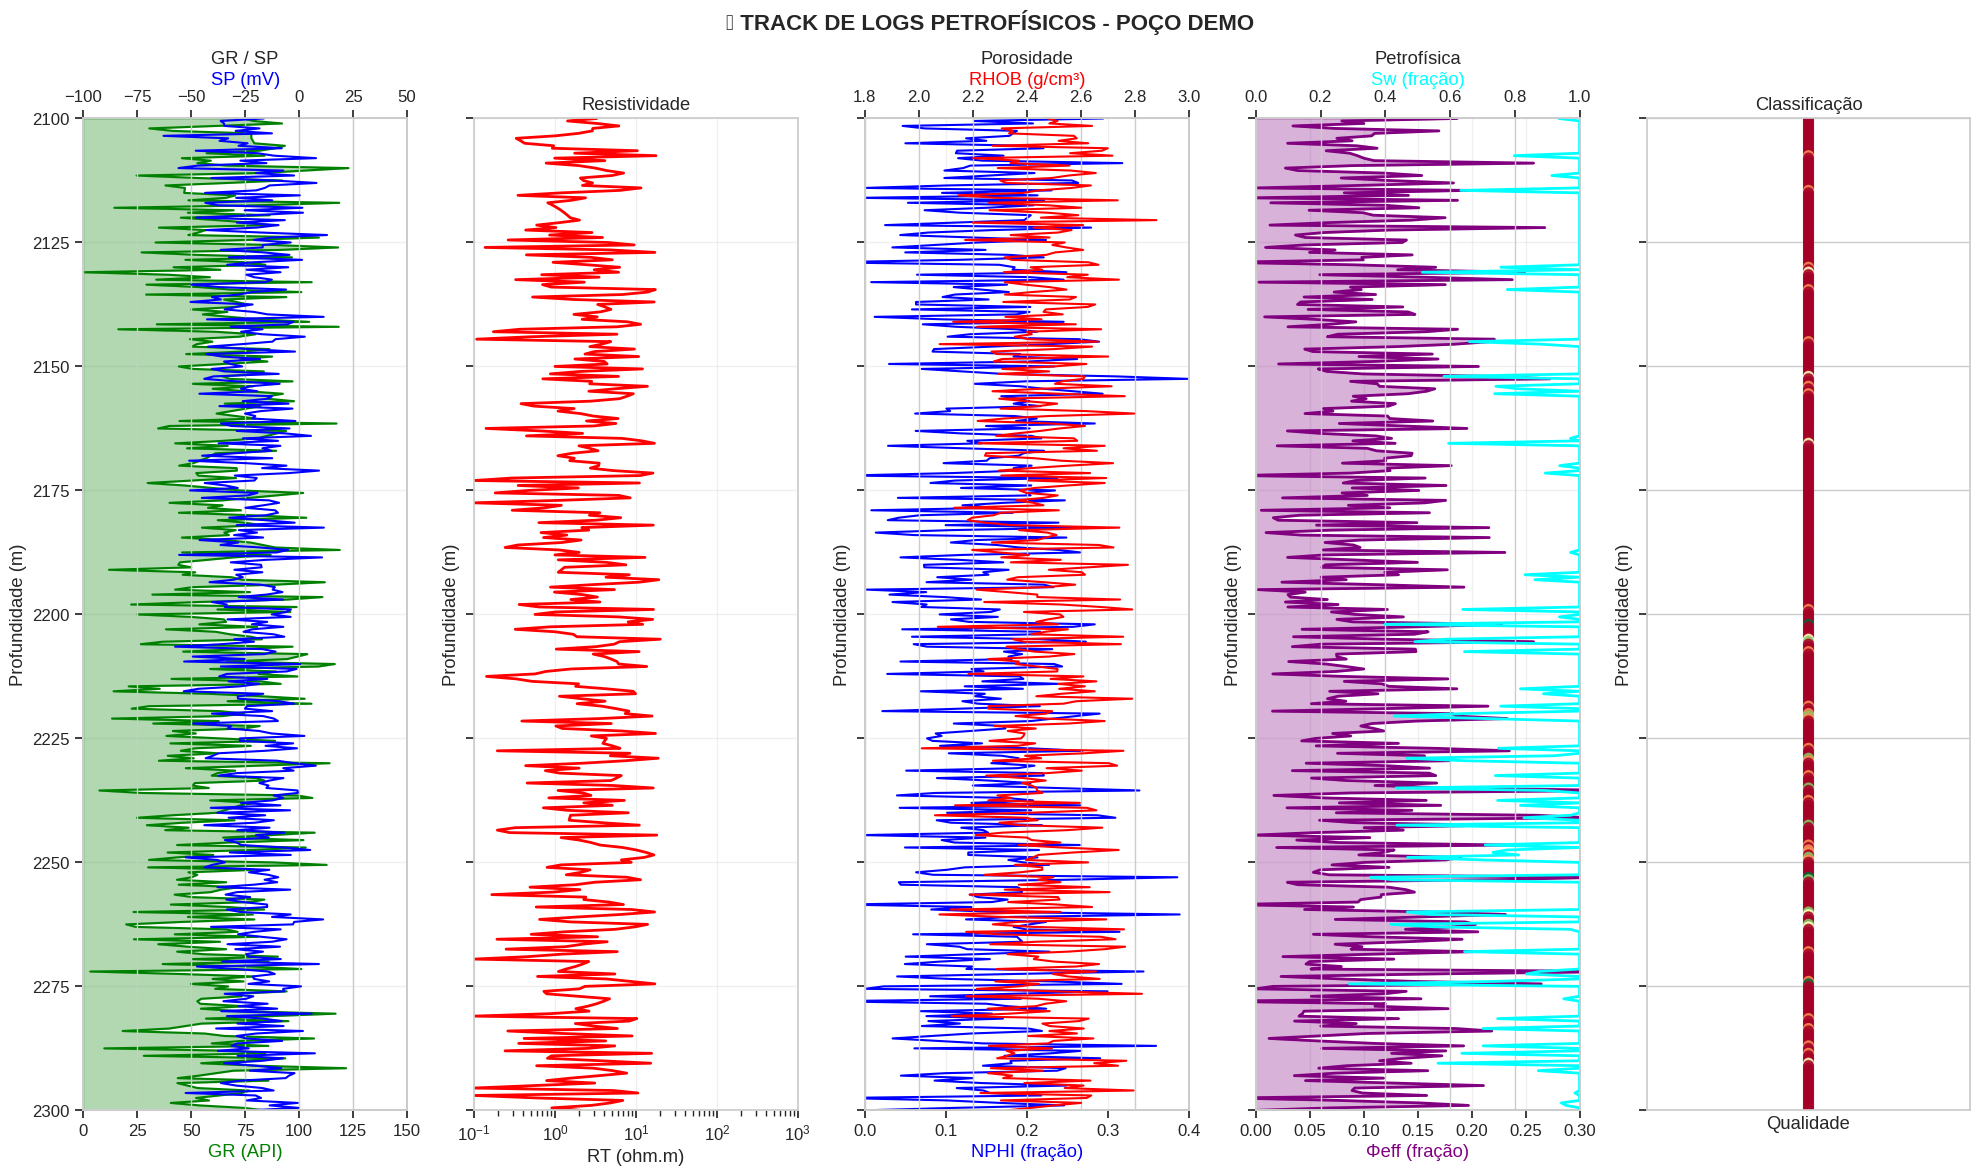

🎯 Track de logs petrofísicos criado!
📊 Visualização profissional estilo indústria


In [19]:
# Visualização específica: Track de logs estilo petrofísico profissional (OPCIONAL)
fig, axes = plt.subplots(1, 5, figsize=(20, 12), sharey=True)
fig.suptitle('📊 TRACK DE LOGS PETROFÍSICOS - POÇO DEMO', fontsize=16, fontweight='bold')

# Definindo intervalo de profundidade para plotagem
# Mask é uma variável Booleana de filtragem, usem-na quando quiserem criar uma visualização
# focada em um intervalo de profundidade específico, evitando plotar o poço inteiro quando
# você quer detalhar uma seção em particular.

prof_min, prof_max = 2100, 2300
mask = (df_features.index >= prof_min) & (df_features.index <= prof_max)
dados_plot = df_features[mask]

# Track 1: Raios Gama e SP
ax1 = axes[0]
ax1.plot(dados_plot['GR'], dados_plot.index, 'g-', linewidth=1.5, label='GR')
ax1.fill_betweenx(dados_plot.index, 0, dados_plot['GR'], alpha=0.3, color='green')
ax1_twin = ax1.twiny()
ax1_twin.plot(dados_plot['SP'], dados_plot.index, 'b-', linewidth=1.5, label='SP')
ax1.set_xlim(0, 150)
ax1_twin.set_xlim(-100, 50)
ax1.set_xlabel('GR (API)', color='green')
ax1_twin.set_xlabel('SP (mV)', color='blue')
ax1.set_title('GR / SP')
ax1.grid(True, alpha=0.3)

# Track 2: Resistividade (escala log)
ax2 = axes[1]
ax2.semilogx(dados_plot['RT'], dados_plot.index, 'r-', linewidth=2)
ax2.set_xlim(0.1, 1000)
ax2.set_xlabel('RT (ohm.m)')
ax2.set_title('Resistividade')
ax2.grid(True, alpha=0.3)

# Track 3: Porosidade (Neutrão e Densidade)
ax3 = axes[2]
ax3.plot(dados_plot['NPHI'], dados_plot.index, 'b-', linewidth=1.5, label='NPHI')
ax3_twin = ax3.twiny()
ax3_twin.plot(dados_plot['RHOB'], dados_plot.index, 'r-', linewidth=1.5, label='RHOB')
ax3.set_xlim(0, 0.4)
ax3_twin.set_xlim(1.8, 3.0)
ax3.set_xlabel('NPHI (fração)', color='blue')
ax3_twin.set_xlabel('RHOB (g/cm³)', color='red')
ax3.set_title('Porosidade')
ax3.grid(True, alpha=0.3)

# Track 4: Features calculadas
ax4 = axes[3]
ax4.plot(dados_plot['PHI_EFF'], dados_plot.index, 'purple', linewidth=2, label='Φeff')
ax4.fill_betweenx(dados_plot.index, 0, dados_plot['PHI_EFF'], alpha=0.3, color='purple')
ax4_twin = ax4.twiny()
ax4_twin.plot(dados_plot['SW'], dados_plot.index, 'cyan', linewidth=2, label='Sw')
ax4.set_xlim(0, 0.3)
ax4_twin.set_xlim(0, 1)
ax4.set_xlabel('Φeff (fração)', color='purple')
ax4_twin.set_xlabel('Sw (fração)', color='cyan')
ax4.set_title('Petrofísica')
ax4.grid(True, alpha=0.3)

# Track 5: Litologia e Qualidade
ax5 = axes[4]
# Convertendo qualidade para números para plotting
qualidade_map = {'Não-reservatório': 0, 'Pobre': 1, 'Regular': 2, 'Bom': 3, 'Excelente': 4}
dados_plot_copy = dados_plot.copy()
dados_plot_copy['QUAL_NUM'] = dados_plot_copy['QUALIDADE_RES'].map(qualidade_map)

# Criando colormap customizado
colors_qual = ['gray', 'red', 'orange', 'yellow', 'green']
scatter = ax5.scatter([0.5] * len(dados_plot_copy), dados_plot_copy.index,
                     c=dados_plot_copy['QUAL_NUM'], cmap='RdYlGn', s=50, alpha=0.8)
ax5.set_xlim(0, 1)
ax5.set_xlabel('Qualidade')
ax5.set_title('Classificação')
ax5.set_xticks([])

# Configurações comuns
for ax in axes:
    ax.set_ylim(prof_max, prof_min)  # Invertido (profundidade cresce para baixo)
    ax.set_ylabel('Profundidade (m)')

plt.tight_layout()
plt.show()

print("🎯 Track de logs petrofísicos criado!")
print("📊 Visualização profissional estilo indústria")

## 🏃‍♂️ EXERCÍCIO PRÁTICO 1: ANÁLISE DE RESERVATÓRIO

**Objetivo:** Identificar as melhores zonas produtoras no poço

**Tarefa:** Complete o código abaixo para encontrar os intervalos com maior potencial:

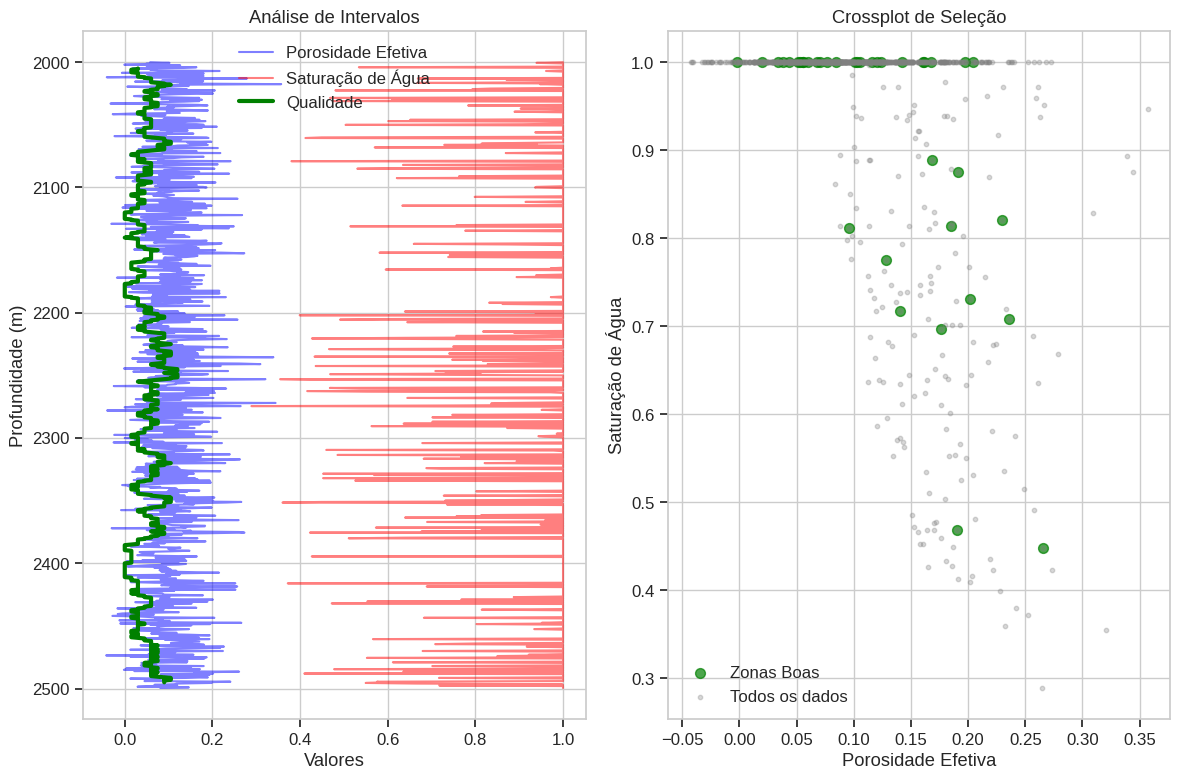

🎯 EXERCÍCIO 1 - Verifique seus critérios!
📊 38 pontos identificados como bons produtores


In [23]:
# EXERCÍCIO 1: Análise de intervalos produtores

def analisar_intervalos_produtores(df, janela_metros=10):
    """
    Encontra intervalos contínuos com bom potencial de produção
    """
    # Convertendo metros para pontos (assumindo step de 0.5m)
    janela_pontos = int(janela_metros / 0.5)

    # Critérios de qualidade (COMPLETE AQUI)
    criterio_phi = df['PHI_EFF'] > 0.05  # Porosidade > 0.05 (muito relaxado)
    criterio_sw = df['SW'] < 0.95     # Saturação água < 0.95 (muito relaxado)
    criterio_vcl = df['VCL'] < 0.7  # Volume argila < 0.7 (muito relaxado)

    # Combinando critérios
    reservatorio_bom = criterio_phi & criterio_sw & criterio_vcl

    # Calculando médias móveis para suavizar
    reservatorio_smooth = reservatorio_bom.rolling(window=janela_pontos, center=True).mean()

    # Identificando intervalos (COMPLETE AQUI)
    intervalos_bom = reservatorio_smooth > 0.3 #Limite da média móvel relaxado para 0.3
    return intervalos_bom, reservatorio_smooth

# TESTE SUA FUNÇÃO:
intervalos, suavizado = analisar_intervalos_produtores(df_features)

# Visualizando resultado
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.plot(df_features['PHI_EFF'], df_features.index, 'b-', alpha=0.5, label='Porosidade Efetiva')
plt.plot(df_features['SW'], df_features.index, 'r-', alpha=0.5, label='Saturação de Água')
plt.plot(suavizado * 0.3, df_features.index, 'g-', linewidth=3, label='Qualidade')
plt.xlabel('Profundidade (m)')
plt.ylabel('Valor')
plt.gca().invert_yaxis()
plt.legend()
plt.title('Análise de Intervalos')
plt.xlabel('Valores')
plt.ylabel('Profundidade (m)')

plt.subplot(1, 2, 2)
zonas_produtoras = df_features[intervalos]
if len(zonas_produtoras) > 0:
    plt.scatter(zonas_produtoras['PHI_EFF'], zonas_produtoras['SW'],
               c='green', s=50, alpha=0.7, label='Zonas Boas')
plt.scatter(df_features['PHI_EFF'], df_features['SW'],
           c='gray', s=10, alpha=0.3, label='Todos os dados')
plt.xlabel('Porosidade Efetiva')
plt.ylabel('Saturação de Água')
plt.title('Crossplot de Seleção')
plt.legend()

plt.tight_layout()
plt.show()

print("🎯 EXERCÍCIO 1 - Verifique seus critérios!")
print(f"📊 {intervalos.sum()} pontos identificados como bons produtores")

## 🏃‍♂️ EXERCÍCIO PRÁTICO 2: CORRELAÇÃO ENTRE POÇOS

**Objetivo:** Comparar dados entre múltiplos poços

**Tarefa:** Implemente uma função para correlacionar logs entre poços diferentes:

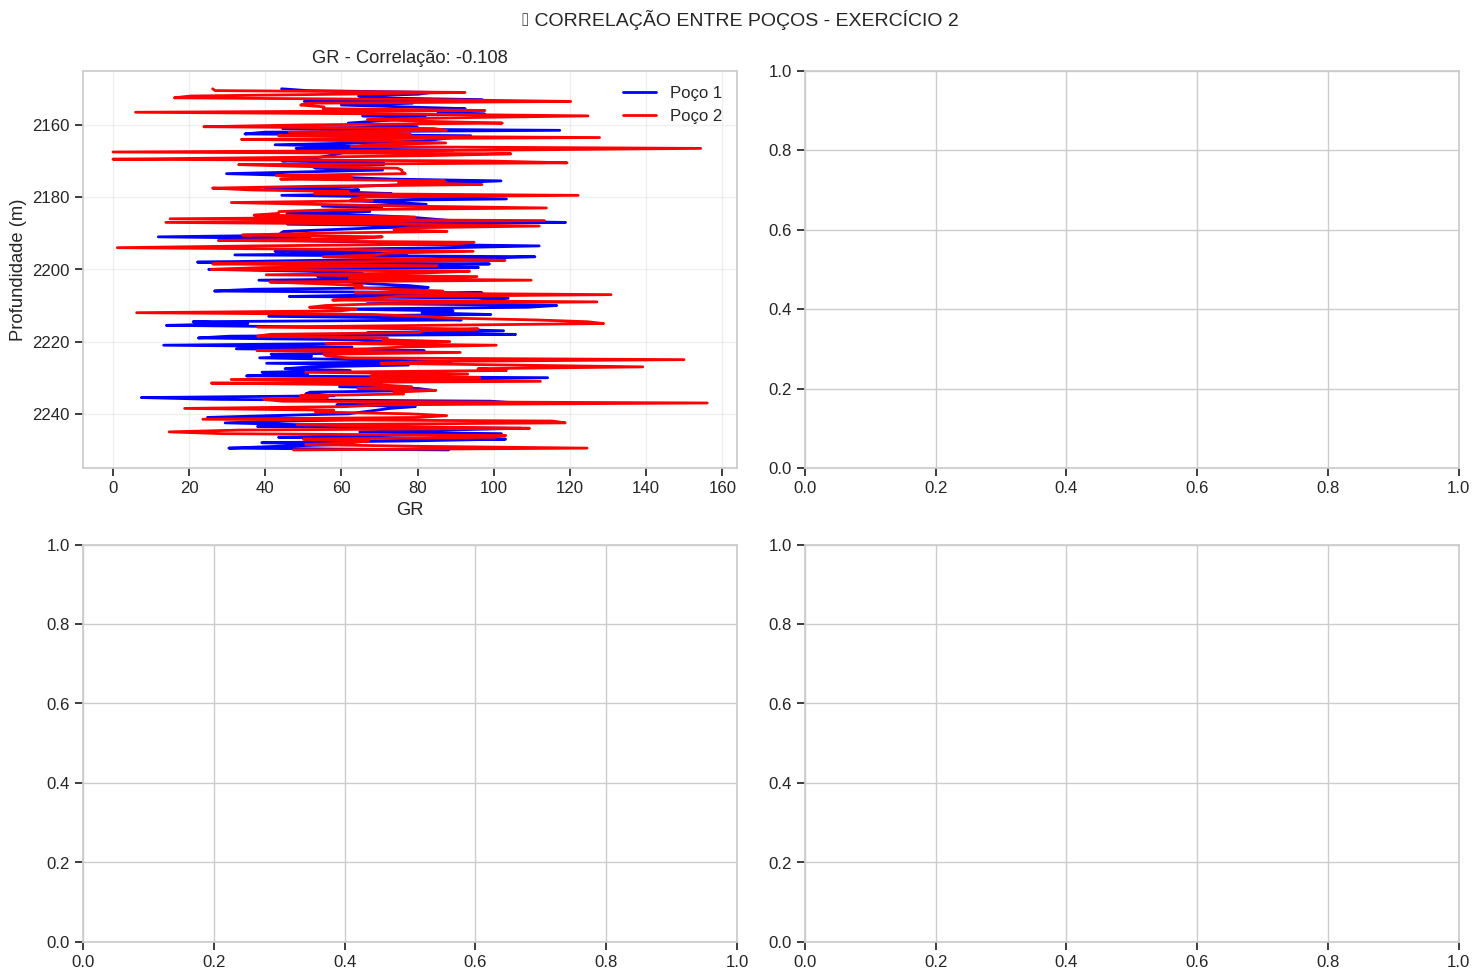

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

🎯 EXERCÍCIO 2 - Análise de correlação entre poços
📊 Correlações calculadas: {'GR': np.float64(-0.10814270956531899), 'RT': np.float64(-0.1292645763443432), 'NPHI': np.float64(0.060756115977162344), 'RHOB': np.float64(0.07722468462785229)}


In [26]:
# EXERCÍCIO 2: Correlação entre poços
# Criando dados de segundo poço para comparação

np.random.seed(456)
prof_poco2 = np.arange(2000, 2500, 0.5)
dados_poco2 = {
    'DEPT': prof_poco2,
    'GR': np.random.normal(70, 30, len(prof_poco2)).clip(0, 200),
    'RT': np.random.lognormal(0.8, 1.2, len(prof_poco2)).clip(0.1, 500),
    'NPHI': np.random.normal(0.18, 0.09, len(prof_poco2)).clip(-0.05, 0.6),
    'RHOB': np.random.normal(2.40, 0.18, len(prof_poco2)).clip(1.8, 3.0),
}

# O que fazemos após criar um conjunto de dados? Aqui estamos interessados no index DEPT

df_pocos2 = pd.DataFrame(dados_poco2).set_index('DEPT')

# COMPLETE A FUNÇÃO DE CORRELAÇÃO:
def correlacionar_pocos(poco1, poco2, profundidade_ref=2200):
    """
    Correlaciona logs entre dois poços em uma profundidade de referência
    """
    # Selecionando janela ao redor da profundidade de referência
    janela = 50  # metros
    prof_min = profundidade_ref - janela
    prof_max = profundidade_ref + janela

    # Filtrando dados (COMPLETE AQUI)
    poco1_janela = poco1.loc[prof_min:prof_max]
    poco2_janela = poco2.loc[prof_min:prof_max]

    # Calculando correlações entre logs principais
    logs_principais = ['GR', 'RT', 'NPHI', 'RHOB']
    correlacoes = {}

    for log in logs_principais:
        # Interpolando para mesmo índice se necessário
        # Para calcular a correlação, os DataFrames devem ter o mesmo índice e as colunas a serem correlacionadas.
        # Reamostramos 'poco2_janela' para alinhar com o índice de 'poco1_janela' para o cálculo da correlação.
        aligned_poco2_log = poco2_janela[log].reindex(poco1_janela.index).interpolate(method='linear')

        corr = poco1_janela[log].corr(aligned_poco2_log)
        correlacoes[log] = corr

    return correlacoes, poco1_janela, poco2_janela

# TESTE SUA FUNÇÃO:
corr_resultado, p1_janela, p2_janela = correlacionar_pocos(df_features, df_pocos2)

# Visualizando correlação
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🔗 CORRELAÇÃO ENTRE POÇOS - EXERCÍCIO 2', fontsize=14)

logs_plot = ['GR', 'RT', 'NPHI', 'RHOB']

# << >> vamos usar função embutida do Python enumerate() que adiciona um contador a um iterável
# (como uma lista) e o retorna como um objeto enumerado. Quando você o usa em um loop for,
# ele retorna pares de (índice, valor).

    # Plotando os dois poços
    # Vamos usar uma técnica muito eficiente e comum para preencher uma grade de gráficos em matplotlib
    # quando você tem uma lista de itens para plotar com axes[i//2, i%2]
    # i//2 Este operador (duas barras) realiza a divisão e arredonda o resultado para o menor número inteiro
    # i%2 Este operador retorna o resto da divisão de i por 2
    # Exemplificando:
    # i = 0: axes[0//2, 0%2] resulta em axes[0, 0] (primeiro subplot, linha 0, coluna 0)
    # i = 1: axes[1//2, 1%2] resulta em axes[0, 1] (segundo subplot, linha 0, coluna 1)

for i, log in enumerate(logs_plot):
      ax = axes[i // 2, i % 2]
      ax.plot(p1_janela[log], p1_janela.index, 'b-', linewidth=2, label='Poço 1')
      ax.plot(p2_janela[log], p2_janela.index, 'r-', linewidth=2, label='Poço 2')
      ax.set_ylabel('Profundidade (m)')
      ax.set_xlabel(f'{log}')
      ax.set_title(f'{log} - Correlação: {corr_resultado.get(log, 0):.3f}')
      ax.legend()
      ax.invert_yaxis()
      ax.grid(True, alpha=0.3)
      plt.tight_layout()
      plt.show()

print("🎯 EXERCÍCIO 2 - Análise de correlação entre poços")
print("📊 Correlações calculadas:", corr_resultado)

In [27]:
# Salvando resultados para próxima aula
# IMPORTANTE: Execute esta célula para salvar seu progresso!

# Exportando DataFrame processado
df_features.to_csv('dados_processados_aula3.csv')

# Salvando estatísticas principais
estatisticas_finais = {
    'total_pontos': len(df_features),
    'intervalo_profundidade': f"{df_features.index.min():.1f} - {df_features.index.max():.1f}m",
    'porosidade_media': df_features['PHI_EFF'].mean(),
    'saturacao_agua_media': df_features['SW'].mean(),
    'intervalos_produtores': len(df_features[df_features['QUALIDADE_RES'].isin(['Bom', 'Excelente'])]),
    'net_to_gross_geral': len(df_features[df_features['QUALIDADE_RES'].isin(['Bom', 'Excelente'])]) / len(df_features)
}

import json
with open('estatisticas_aula3.json', 'w') as f:
    json.dump(estatisticas_finais, f, indent=2)

print("💾 DADOS SALVOS COM SUCESSO!")
print("📁 Arquivos gerados:")
print("   • dados_processados_aula3.csv")
print("   • estatisticas_aula3.json")
print("\n📊 Estatísticas Finais:")
for chave, valor in estatisticas_finais.items():
    print(f"   • {chave}: {valor}")

print("\n🎉 AULA 3 CONCLUÍDA!")
print("🚀 Pronto para Aula 4: Visualização Avançada")
print("💡 Não esqueça de salvar este notebook no Google Colab!")

💾 DADOS SALVOS COM SUCESSO!
📁 Arquivos gerados:
   • dados_processados_aula3.csv
   • estatisticas_aula3.json

📊 Estatísticas Finais:
   • total_pontos: 1000
   • intervalo_profundidade: 2000.0 - 2499.5m
   • porosidade_media: 0.10480310853535878
   • saturacao_agua_media: 0.9484005704121844
   • intervalos_produtores: 29
   • net_to_gross_geral: 0.029

🎉 AULA 3 CONCLUÍDA!
🚀 Pronto para Aula 4: Visualização Avançada
💡 Não esqueça de salvar este notebook no Google Colab!
